# **Multiple Instance Deep AUC Maximization with softmax pooling (MIDAM-smx) on Tabular Dataset**

**Author**: Dixian Zhu \
**Edited by**: Zhuoning Yuan 

**Introduction**

In this tutorial, we will learn how to quickly train a simple Feed Forward Neural Network (FFNN) model by optimizing **Multiple Instance Deep AUC Maximization (MIDAM)** under our novel `MIDAMLoss(mode='softmax')` and `MIDAM` optimizer [[Ref]](https://arxiv.org/abs/2305.08040) method on a binary classification task on MUSK2 dataset. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:
   
If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:

```
@inproceedings{zhu2023provable,
  title={Provable Multi-instance Deep AUC Maximization with Stochastic Pooling},
  author={Zhu, Dixian and Wang, Bokun and Chen, Zhi and Wang, Yaxing and Sonka, Milan and Wu, Xiaodong and Yang, Tianbao},
  booktitle={International Conference on Machine Learning},
  pages={},
  year={2023},
  organization={PMLR}
}

```

# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from libauc.optimizers import MIDAM
from libauc.losses import MIDAMLoss
from libauc.models import FFNN
from libauc.utils import set_all_seeds, collate_fn, MIL_sampling, MIL_evaluate_auc
from libauc.sampler import DualSampler
from libauc.datasets import MUSK2, CustomDataset

# **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [ ]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# **HyperParameters**

The hyper-parameters: batch size (bag-level), instance batch size (instance-level), postive sampling rate, learning rate, weight decay and margin for AUC loss.

In [ ]:
# HyperParameters
SEED = 123
set_all_seeds(SEED)
batch_size = 16
instance_batch_size = 4
sampling_rate = 0.5
lr = 1e-2
weight_decay = 1e-4
margin = 1.0
tau = 0.1
momentum = 0.1
gamma = 0.9

# **Load Data, initialize model and loss**

In this step, we will use the MUSK2 as benchmark dataset [[Ref]](https://archive.ics.uci.edu/ml/datasets/Musk+(Version+2) Import data to dataloader. We extend the traditional FFNN with an additional attention module: FFNN_stoc_att. Data format: a list with length equals to number of bags. Each bag is an array with shape: (Number of instances for this bag, Dimension)

In [ ]:
(train_data, train_labels), (test_data, test_labels) = MUSK2()
traindSet = CustomDataset(train_data, train_labels, return_index=True)
testSet = CustomDataset(test_data, test_labels, return_index=True)
DIMS=166

sampler = DualSampler(dataset=traindSet, batch_size=batch_size, shuffle=True, sampling_rate=sampling_rate)
trainloader =  torch.utils.data.DataLoader(dataset=traindSet, sampler=sampler, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
testloader =  torch.utils.data.DataLoader(testSet, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FFNN(input_dim=DIMS, hidden_sizes=(DIMS, ), num_classes=1, last_activation='sigmoid').to(device)
Loss = MIDAMLoss(mode='softmax',data_len=len(traindSet), tau=tau, margin=margin, gamma=gamma)
optimizer = MIDAM(model.parameters(), loss_fn=Loss, lr=lr, weight_decay=weight_decay, momentum=momentum)

100%|██████████| 9154522/9154522 [00:00<00:00, 44566294.02it/s]


# **Training**

In [ ]:
total_epochs = 100
decay_epoch = [50, 75]
train_auc = np.zeros(total_epochs)
test_auc = np.zeros(total_epochs)
for epoch in range(total_epochs):
    if epoch in decay_epoch:
        optimizer.update_lr(decay_factor=10)
        Loss.update_smoothing(decay_factor=2)
    tr_loss = 0
    for idx, data in enumerate(trainloader):
        y_pred = []
        train_data_bags, train_labels, ids = data
        for i in range(len(ids)):
            tmp_pred = MIL_sampling(bag_X=train_data_bags[i], model=model, instance_batch_size=instance_batch_size, tau=tau, mode='exp')
            y_pred.append(tmp_pred)
        y_pred = torch.cat(y_pred, dim=0)
        ids = torch.from_numpy(np.array(ids))
        train_labels = torch.from_numpy(np.array(train_labels))
        loss = Loss(y_pred=y_pred, y_true=train_labels, index=ids)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        tr_loss += loss.detach().cpu().numpy()

    model.eval()
    with torch.no_grad():
        single_tr_auc = MIL_evaluate_auc(trainloader, model, mode='softmax', tau=tau)
        single_te_auc = MIL_evaluate_auc(testloader, model, mode='softmax', tau=tau)
    train_auc[epoch] = single_tr_auc
    test_auc[epoch] = single_te_auc
    model.train()
    tr_loss = tr_loss/idx
    print ('Epoch=%s, BatchID=%s, loss=%.4f, Tr_AUC=%.4f, Test_AUC=%.4f, lr=%.4f'%(epoch, idx, tr_loss, single_tr_auc, single_te_auc,  optimizer.lr))

Epoch=0, BatchID=5, loss=0.3744, Tr_AUC=0.3980, Test_AUC=0.2083, lr=0.0100
Epoch=1, BatchID=5, loss=0.0948, Tr_AUC=0.3668, Test_AUC=0.1667, lr=0.0100
Epoch=2, BatchID=5, loss=0.0417, Tr_AUC=0.3529, Test_AUC=0.2083, lr=0.0100
Epoch=3, BatchID=5, loss=0.0246, Tr_AUC=0.3750, Test_AUC=0.2083, lr=0.0100
Epoch=4, BatchID=5, loss=0.0160, Tr_AUC=0.4657, Test_AUC=0.2083, lr=0.0100
Epoch=5, BatchID=5, loss=0.0099, Tr_AUC=0.4162, Test_AUC=0.2500, lr=0.0100
Epoch=6, BatchID=5, loss=0.0058, Tr_AUC=0.5820, Test_AUC=0.2500, lr=0.0100
Epoch=7, BatchID=5, loss=0.0068, Tr_AUC=0.5195, Test_AUC=0.2500, lr=0.0100
Epoch=8, BatchID=5, loss=0.0050, Tr_AUC=0.5590, Test_AUC=0.2500, lr=0.0100
Epoch=9, BatchID=5, loss=0.0061, Tr_AUC=0.5851, Test_AUC=0.2917, lr=0.0100
Epoch=10, BatchID=5, loss=0.0056, Tr_AUC=0.6220, Test_AUC=0.2917, lr=0.0100
Epoch=11, BatchID=5, loss=0.0076, Tr_AUC=0.7335, Test_AUC=0.2917, lr=0.0100
Epoch=12, BatchID=5, loss=0.0078, Tr_AUC=0.7439, Test_AUC=0.2917, lr=0.0100
Epoch=13, BatchID=5, l

# **Visualization**

Text(0.5, 0, 'epochs')

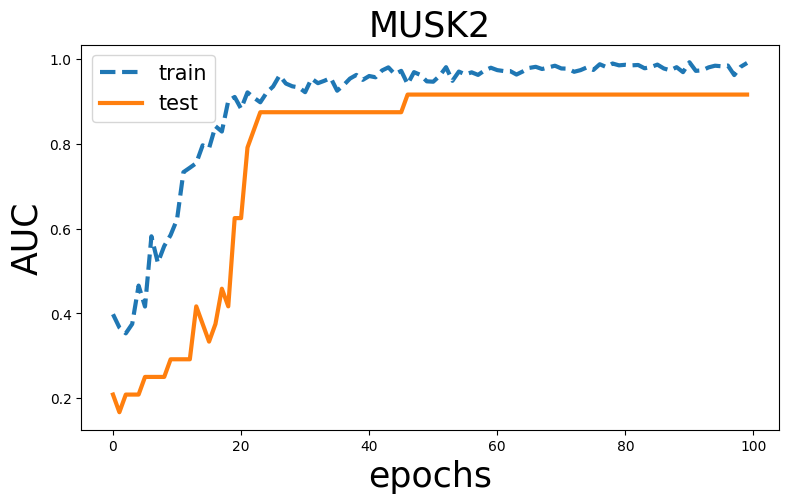

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9,5)
x=np.arange(len(train_auc))

plt.figure()
plt.plot(x, train_auc, linestyle='--', label='train', linewidth=3)
plt.plot(x, test_auc, label='test', linewidth=3)
plt.title('MUSK2',fontsize=25)
plt.legend(fontsize=15)
plt.ylabel('AUC',fontsize=25)
plt.xlabel('epochs',fontsize=25)